# TL;DR;

Kanpig's use of k=4 kmers was causing it to have a hard time consistently choosing the same paths between haplotypes. After refactoring kanpig's code to (reasonably) allow k upto 32, we ran experiments on simulated tandem repeats and show that setting `--kmer 16` and `--minkfreq 1` raises the rate that kanpig picks the same paths between haplotypes from ~82% to ~93%.

# Problem

The Kmer Vectors and Canberra similarity were shown to correlate highly with plain sequence similarity. So we believe that it gives a good measure of the similarity between a haplotype and a path. 

However, as the VCF (graph) grows in sample size, there appeared to be instability in haplotype application to the graph. This was observed via mendelian consistency of trios being low within a multi-sample VCF. A shared SV across e.g. Mother/Proband was being represented differently across the two individuals. That is to say, the "same" haplotypes were being applied to two different paths in the graph. This problem was observed to be amplified in tandem repeat sequences.

There's for-sure work that can be done to better identify/collapse putatively redundant SVs so that kanpig doesn't have the opportunity to choose different paths. The Broad AoU solution was essentially this by creating "Personalized Graphs" for each individual. However, this comes at a cost of high missingness rate in the resultant pVCF.

After exploring a few different ideas, I've discovered a fix for this problem.

## Setup:

We simulate a tandem repeats locus where given a motif size, copy number, and mutation rate we create a 'backbone' sequence (see `simulate_seqs.simulate_tandem_repeat_noisy`). 

We then randomly alter this backbone sequence with a 5% mutation rate and expansion/contraction of upto 5 copies of the motif. We repeat this alteration 10 times to create a database of sequences which emulates the set of paths kanpig would need to check in a graph during genotyping. 

We then choose one of these sequences to be our target. This represents the path that kanpig should be matching to. We then mutate that target sequence twice at a lower rate (0.02 mutation, ±2 copies of motif) to simulate sequencing noise. This creates our two query squences. 

We then calculate the similarity score of the queries against all of the database sequences. We then check if both queries hit the same, correct target sequence. We repeat this simulation/evaluation 1,000x to collect a correct rate - this comprises an experiment.

We repeat the experiments with diferent motif sizes (2,3,5,8) and copy numbers (20, 40, 60, 80, 120). We also repeat each of those experiments with different kmer sizes for the kanpig work (3, 4, 6, 8, 12, 16, 24). 

Below we show that the problem of not picking consistent paths is due to a low kmer-size. After refactoring the kanpig code, we can now turn sequences into kmers upto k=32bp with zero runtime cost. We have changed kanpig's default `--kmer` size 16.

The main measurements below are on the same AND correct target sequence being hit by the queries. However, it's important to note that if we loosen the criteria to only measuring the rate that kanpig would pick the same target sequence, irrespective of if its correct, we see the final accuracy rate being even higher. 

|measure |  k=4   | k=16 |
|--------|--------|------|
| S+C    |   82   | 93   |
| S      |   86   | 95   |

As part of the fix, the `--minkfreq` parameter is also shown to have a large impact on kanpig's ability to consistenty choose the correct path to which haplotypes are applied. We changed that parameter's default value to 1. Future experiments need to assess if this parameter is actually important to be 2 sometimes when e.g. the sequencing error rate is higher. I'd do this by simulating the queries at a slightly higher error rate.

Future ToDos: I need to make the queries a little more realistic. How I'm changing them currently isn't super reflective of the sequencing noise / alignment ambiguity we'd actuallly see in real data. It's just a flat mutation rate, I'm sort of making indel errors, but they're of the motif, and not real 1bp ins/del made by long-read technologies.

# New Problems

The higher k means a thinner sampling of the sequence, meaning higher deviation from sequence similarity. All that's to say that with k=16, it's harder for a haplotype to have 90% sequence similarity to a path.

Options:
1. Lower the default seqsim, maybe even to the point that we turn it off
2. Figure out how to make that seqsim make sense at higher k
3. Abandon the whole idea... IDK.

I guess, let's turn off seqsim and keep with the k=4/k=16 tests with trio mode vs independent. A.k.A. punt on this problem.

# Even more problems

So, lowering seqsim helps. But now the functional tests for mosaic and trio are performing worse. I think it could be because of the joint clustering. But also, because gt mode is actually doing better (as this document's experiments expected). So I'm also suspicious of if the measurements against plat and mims are lower, but more accurate.

In [5]:
%%bash
# Run the experiment
mkdir -p sims
# Header
echo motif copynumber kmer invalid odd tests same samecorr > table.txt
# Motif Size
for m in 2 3 5 8;
do
    # Copy Number
    for n in 20 40 60 80 120;
    do
        # Kmer
        for i in 3 4 6 8 12 16 24;
        do
            echo -n $m $n $i ""
            python simulate_seqs.py --mink 2 \
                                    --motif-length $m \
                                    --n-repeats $n \
                                    --kmer-size $i \
                                    --brief --seed 23827 \
                                    --write-sim sims/sim.$m.$n.$i.tsv \
                >> table.txt
        done
    done
done

2 20 3 2 20 4 2 20 6 2 20 8 2 20 12 2 20 16 2 20 24 2 40 3 2 40 4 2 40 6 2 40 8 2 40 12 2 40 16 2 40 24 2 60 3 2 60 4 2 60 6 2 60 8 2 60 12 2 60 16 2 60 24 2 80 3 2 80 4 2 80 6 2 80 8 2 80 12 2 80 16 2 80 24 2 120 3 2 120 4 2 120 6 2 120 8 2 120 12 2 120 16 2 120 24 3 20 3 3 20 4 3 20 6 3 20 8 3 20 12 3 20 16 3 20 24 3 40 3 3 40 4 3 40 6 3 40 8 3 40 12 3 40 16 3 40 24 3 60 3 3 60 4 3 60 6 3 60 8 3 60 12 3 60 16 3 60 24 3 80 3 3 80 4 3 80 6 3 80 8 3 80 12 3 80 16 3 80 24 3 120 3 3 120 4 3 120 6 3 120 8 3 120 12 3 120 16 3 120 24 5 20 3 5 20 4 5 20 6 5 20 8 5 20 12 5 20 16 5 20 24 5 40 3 5 40 4 5 40 6 5 40 8 5 40 12 5 40 16 5 40 24 5 60 3 5 60 4 5 60 6 5 60 8 5 60 12 5 60 16 5 60 24 5 80 3 5 80 4 5 80 6 5 80 8 5 80 12 5 80 16 5 80 24 5 120 3 5 120 4 5 120 6 5 120 8 5 120 12 5 120 16 5 120 24 8 20 3 8 20 4 8 20 6 8 20 8 8 20 12 8 20 16 8 20 24 8 40 3 8 40 4 8 40 6 8 40 8 8 40 12 8 40 16 8 40 24 8 60 3 8 60 4 8 60 6 8 60 8 8 60 12 8 60 16 8 60 24 8 80 3 8 80 4 8 80 6 8 80 8 8 80 12 8 80 16

In [10]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

count    20.000000
mean      0.826584
std       0.114876
min       0.654000
25%       0.743116
50%       0.844409
75%       0.918500
max       0.971000
Name: acc, dtype: float64
count    20.000000
mean      0.934091
std       0.085071
min       0.672316
25%       0.908624
50%       0.971107
75%       0.994996
max       1.000000
Name: acc, dtype: float64
count    20.000000
mean      0.869510
std       0.083412
min       0.735876
25%       0.799719
50%       0.882267
75%       0.933250
max       0.978000
dtype: float64
count    20.000000
mean      0.953055
std       0.058528
min       0.778249
25%       0.931740
50%       0.976296
75%       0.996249
max       1.000000
dtype: float64


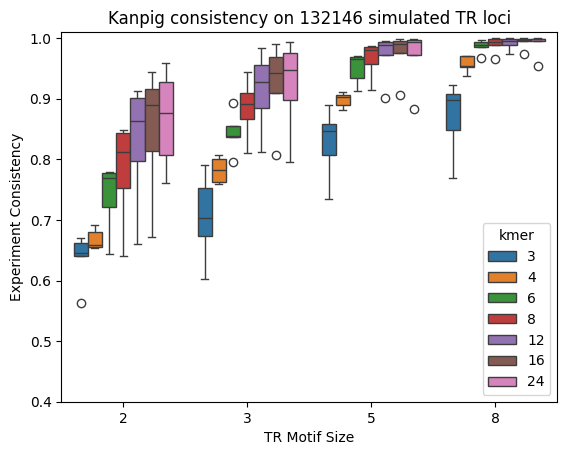

In [30]:
data = pd.read_csv("table.minkfreq1.txt", sep=' ')
data['kmer'] = data['kmer'].astype(str)
data['acc'] = data['samecorr'] / data['tests']

p = sb.boxplot(data=data, x='motif', y='acc', hue='kmer')
_ = p.set(title=f"Kanpig consistency on {data['tests'].sum()} simulated TR loci",
          ylabel="Experiment Consistency",
          xlabel="TR Motif Size",
         ylim=(0.4, 1.01))

print(data[data['kmer'] == '4']['acc'].describe())
print(data[data['kmer'] == '16']['acc'].describe())
print((data[data['kmer'] == '4']['same'] / data[data['kmer'] == '4']['tests']).describe())
print((data[data['kmer'] == '16']['same'] / data[data['kmer'] == '16']['tests']).describe())

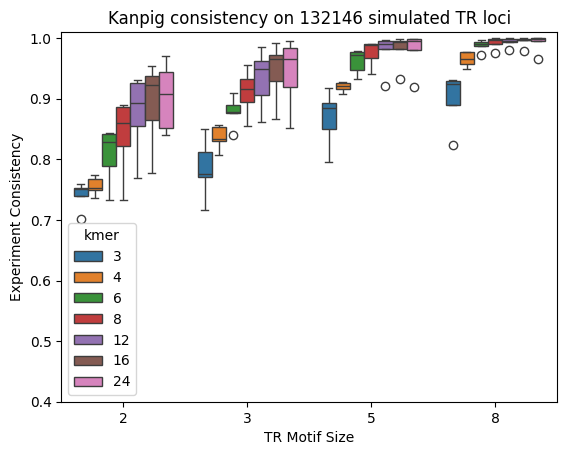

In [23]:
data = pd.read_csv("table.minkfreq1.txt", sep=' ')
data['kmer'] = data['kmer'].astype(str)
data['acc'] = data['same'] / data['tests']

p = sb.boxplot(data=data, x='motif', y='acc', hue='kmer')
_ = p.set(title=f"Kanpig consistency on {data['tests'].sum()} simulated TR loci",
          ylabel="Experiment Consistency",
          xlabel="TR Motif Size",
         ylim=(0.4, 1.01))

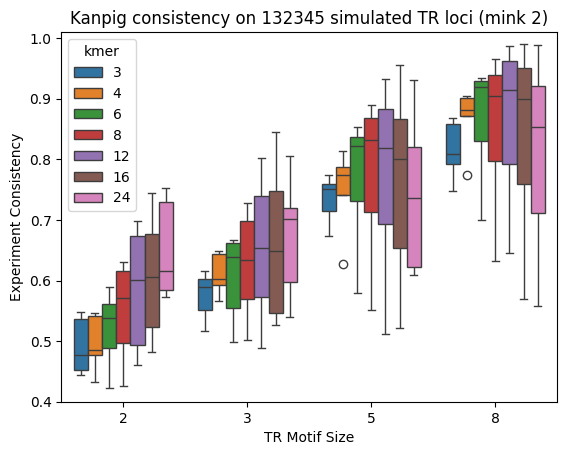

In [18]:
data = pd.read_csv("table.minkfreq2.txt", sep=' ')
data['kmer'] = data['kmer'].astype(str)
data['acc'] = data['samecorr'] / data['tests']

p = sb.boxplot(data=data, x='motif', y='acc', hue='kmer')
_ = p.set(title=f"Kanpig consistency on {data['tests'].sum()} simulated TR loci (mink 2)",
          ylabel="Experiment Consistency",
          xlabel="TR Motif Size",
         ylim=(0.4, 1.01))

In [6]:
# Correlation to sequence sim

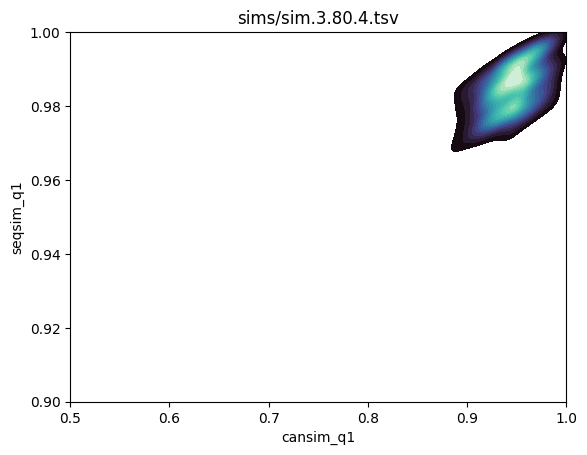

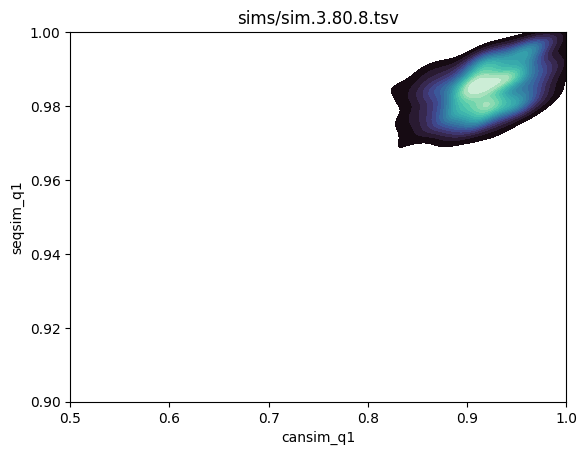

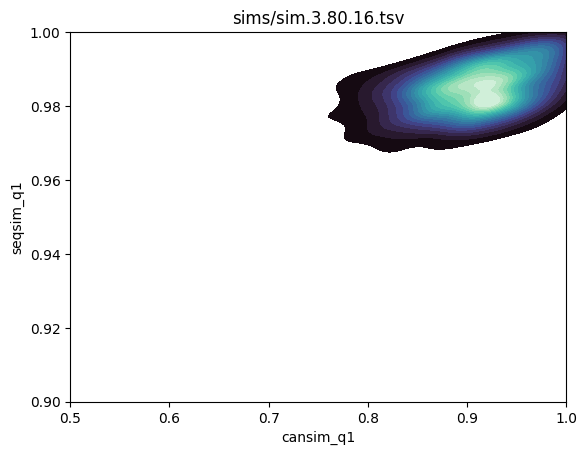

In [29]:
import glob

for i in ["sims/sim.3.80.4.tsv", "sims/sim.3.80.8.tsv", "sims/sim.3.80.16.tsv"]:
    t = pd.read_csv(i, sep='\t')
    fig, ax = plt.subplots()
    p = sb.kdeplot(data=t, x='cansim_q1', y='seqsim_q1', 
                   fill=True, cmap="mako", thresh=0.05, levels=20, ax=ax)
    p.set(title=i, xlim=(0.5, 1), ylim=(0.9, 1))
    plt.show()